<a href="https://colab.research.google.com/github/timfitz04/Business-Analytics-Dissertation/blob/main/FinalCode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Connecting GDrive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.chdir("/content/drive/MyDrive/Dissertation")
!pwd

/content/drive/MyDrive/Dissertation


In [ ]:
!pip install bs4

# Importing Packages

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import geopandas as gpd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA




# Combining Countries

In this section I am joining all the data from all the counties:


*   Dublin
*   Cork
*   Kerry
*   Wicklow
*   Cavan
*   Meath

Also checking the data and removing rows that have blank data.

Rows removed were the team Beara in Cork, this was removed because it is a collection of different clubs within Cork and only appears once all the way back in 2011. And the only other rows removed were for BYEs in Dublin as they do not represent any team





In [ ]:
df_meath = pd.read_csv("/content/drive/MyDrive/Dissertation/Meath/Meath_league_tables.csv")
df_kerry = pd.read_csv("/content/drive/MyDrive/Dissertation/Kerry/kerry_league_tables.csv")
df_cavan = pd.read_csv("/content/drive/MyDrive/Dissertation/Cavan/cavan_league_tables.csv")
df_dublin = pd.read_csv("/content/drive/MyDrive/Dissertation/Dub/Dub_league_tables.csv")
df_wicklow = pd.read_csv("/content/drive/MyDrive/Dissertation/Wicklow/wicklow_leagues.csv")
df_cork = pd.read_csv("/content/drive/MyDrive/Dissertation/Cork/Cork_gaa_leagues.csv")

combined = pd.concat([df_meath, df_kerry, df_cavan ,df_dublin, df_wicklow, df_cork], ignore_index=True)


In [ ]:
print(combined.shape)
print(combined.columns)
print(combined.dtypes)
print(combined.info())
print(combined.isnull().sum())

(4988, 15)
Index(['County', 'Division', 'Year', 'team', 'pld', 'w', 'd', 'l', 'pf', 'pa',
       'pd', 'pts', 'clean_team', 'Latitude', 'Longitude'],
      dtype='object')
County         object
Division       object
Year            int64
team           object
pld             int64
w               int64
d               int64
l               int64
pf              int64
pa              int64
pd              int64
pts             int64
clean_team     object
Latitude      float64
Longitude     float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4988 entries, 0 to 4987
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   County      4988 non-null   object 
 1   Division    4988 non-null   object 
 2   Year        4988 non-null   int64  
 3   team        4988 non-null   object 
 4   pld         4988 non-null   int64  
 5   w           4988 non-null   int64  
 6   d           4988 non-null   int64  
 7   l  

In [ ]:
combined[combined[["Latitude", "Longitude"]].isna().any(axis=1)]

,County,Division,Year,team,pld,w,d,l,pf,pa,pd,pts,clean_team,Latitude,Longitude
1790,Dublin,Division 11S,2023,Bye,14,0,0,13,0,0,0,0,bye,NaN,NaN
1934,Dublin,Division 9,2022,Bye,15,0,0,14,0,0,0,0,bye,NaN,NaN
2109,Dublin,Division 7S,2021,Bye,7,0,0,7,0,0,0,0,bye,NaN,NaN
2151,Dublin,Division 10N,2021,Bye,9,0,0,9,0,0,0,0,bye,NaN,NaN
2161,Dublin,Division 10S,2021,Bye,8,0,0,8,0,0,0,0,bye,NaN,NaN
2171,Dublin,Division 11N G1,2021,Bye,7,0,1,6,1,36,-35,1,bye,NaN,NaN
2181,Dublin,Division 11N G2,2021,Bye,9,0,0,9,0,0,0,0,bye,NaN,NaN
2191,Dublin,Division 11S G1,2021,Bye,9,0,0,9,0,0,0,0,bye,NaN,NaN
2201,Dublin,Division 11S G2,2021,Bye,9,0,1,8,0,0,0,1,bye,NaN,NaN
2359,Dublin,Division 10,2019,Bye,15,0,0,15,0,0,0,0,bye,NaN,NaN


In [ ]:
combined = combined.dropna(subset=["Latitude", "Longitude"])

In [ ]:
print(combined.isnull().sum())

County        0
Division      0
Year          0
team          0
pld           0
w             0
d             0
l             0
pf            0
pa            0
pd            0
pts           0
clean_team    0
Latitude      0
Longitude     0
dtype: int64


# Labelling success

This code creates a label identifying “successful teams.”
It does this in three steps:

1.Calculate Win Percentage
Uses matches played (pld) and wins (w) to compute a team's win rate.

2.Determine Success Threshold
Teams are grouped by Year and Division so they are compared only against teams in the same season and competition level.
The 75th percentile (top 25%) win percentage is calculated for each group.

3.Label Successful Teams
Any team with a win percentage greater than or equal to the 75th percentile is labeled as successful_team = 1.
All other teams receive 0.

In [ ]:
combined['Win Percentage'] = np.where(combined['pld'] == 0, 0, (combined['w'] / combined['pld'])*100)

print(combined[['pld', 'w', 'pts', 'Win Percentage']].head())

   pld  w  pts  Win Percentage
0   11  7   15       63.636364
1   11  7   15       63.636364
2   11  5   14       45.454545
3   11  6   14       54.545455
4   11  5   13       45.454545


In [ ]:
combined.head(10)

,County,Division,Year,team,pld,w,d,l,pf,pa,pd,pts,clean_team,Latitude,Longitude,Win Percentage
0,Meath,Division 1,2024,Skryne,11,7,1,3,151,133,18,15,skryne,53.583364,-6.547767,63.636364
1,Meath,Division 1,2024,Summerhill,11,7,1,3,168,155,13,15,summerhill,53.483525,-6.738941,63.636364
2,Meath,Division 1,2024,Ballinabrackey,11,5,4,2,147,120,27,14,ballinabrackey,53.396387,-7.108494,45.454545
3,Meath,Division 1,2024,Donaghmore/Ashbourne,11,6,2,3,153,127,26,14,donaghmoreashbourne,53.509430,-6.410494,54.545455
4,Meath,Division 1,2024,Ratoath,11,5,3,3,136,128,8,13,ratoath,53.510425,-6.478256,45.454545
5,Meath,Division 1,2024,"St Peter's, Dunboyne",11,5,1,5,171,159,12,11,st peters dunboyne,53.410506,-6.474412,45.454545
6,Meath,Division 1,2024,St. Colmcille's,11,4,2,5,138,139,-1,10,st colmcilles,53.696083,-6.279859,36.363636
7,Meath,Division 1,2024,Na Fianna CLG,11,4,2,5,152,161,-9,10,na fianna enfield,53.410992,-6.822061,36.363636
8,Meath,Division 1,2024,Gaeil Colmcille,11,4,2,5,145,162,-17,10,gaeil colmcille,53.719870,-6.880174,36.363636
9,Meath,Division 1,2024,Bhulf Tón Clg,11,4,2,5,122,141,-19,10,wolfe tones,53.699722,-6.682203,36.363636


# Converting Spatial Data

Convert club latitude and longitude into a spatial dataset using GeoPandas.

Create a 2 km buffer around each club location.

Count how many other clubs are within 2 km to measure local club.

Import Census Small Area data for 2011, 2016, and 2022.

Use spatial joins to identify which small areas fall inside each club's 2 km buffer.

Aggregate census variables within each buffer, including:

-population

-males aged 15-18

-males aged 19-34

-completed secondary education

-employment

-unemployment

Combine the census results from all three years into one dataset.

Interpolate missing years to estimate values between census years.

Extend the trend beyond 2022 to estimate values for later seasons.

Merge these demographic variables with the club performance dataset to create the final analysis dataset.

In [ ]:
# Convert the dataframe into a GeoDataFrame using longitude and latitude
clubs = gpd.GeoDataFrame(
    combined,
    geometry=gpd.points_from_xy(combined['Longitude'], combined['Latitude']),
    crs="EPSG:4326"
)
# Convert coordinate system to Irish Transverse Mercator (meters)
clubs = clubs.to_crs(2157)

# Load the Small Area spatial file
sa = gpd.read_file("/content/drive/MyDrive/Dissertation/Dub/Small_Area_2022.gpkg")

# Convert it to the same coordinate system
sa = sa.to_crs(2157)

# Create a 2 km buffer around each club
clubs['buffer'] = clubs.geometry.buffer(2000)
# Use the buffer column as the geometry
buffers = clubs.set_geometry('buffer')


In [ ]:
#Load the 2022 census data
census_2022 = pd.read_csv("/content/drive/MyDrive/Dissertation/Dub/SAPS_2022_Small_Area.csv")

#Join census data to the small area map
sa_2022 = sa.merge(census_2022, left_on="SA_PUB2022", right_on="GEOGID", how="left")

# Spatial join: connect club buffers to small areas they intersect with
joined_2022 = gpd.sjoin(buffers, sa_2022, how="left", predicate="intersects")

# Remove duplicate small area-team matches
joined_2022 = joined_2022.drop_duplicates(subset=["SA_PUB2022", "team"])

# Total population inside each club buffer
pop_2022 = joined_2022.groupby("team")["T1_1AGETT"].sum().reset_index()
pop_2022 = pop_2022.rename(columns={"T1_1AGETT": "population"})
pop_2022["Year"] = 2022

# joined_2022["male_pop"] =(
#     joined_2022["T1_1AGETM"]
# )
# male_pop = joined_2022.groupby("team")["male_pop"].sum().reset_index()
# Males aged 15-18
joined_2022["male_15_18"] = (
    joined_2022["T1_1AGE15M"] +
    joined_2022["T1_1AGE16M"] +
    joined_2022["T1_1AGE17M"] +
    joined_2022["T1_1AGE18M"]
    )
male_15_18_2022 = joined_2022.groupby("team")["male_15_18"].sum().reset_index()

# Males aged 19-34
joined_2022["male_19_24"] = (
    joined_2022["T1_1AGE19M"] +
    joined_2022["T1_1AGE20_24M"]
)
male_19_24_2022 = joined_2022.groupby("team")["male_19_24"].sum().reset_index()

joined_2022["male_25_34"] = (
    joined_2022["T1_1AGE25_29M"] +
    joined_2022["T1_1AGE30_34M"])
male_25_34_2022 = joined_2022.groupby("team")["male_25_34"].sum().reset_index()
# Completed secondary or higher
joined_2022["completed_secondary_or_higher"] = (
    joined_2022["T10_4_UST"] +
    joined_2022["T10_4_TVT"] +
    joined_2022["T10_4_ACCAT"] +
    joined_2022["T10_4_HCT"] +
    joined_2022["T10_4_ODNDT"] +
    joined_2022["T10_4_HDPQT"] +
    joined_2022["T10_4_PDT"] +
    joined_2022["T10_4_DT"]
)
secondary_2022 = joined_2022.groupby("team")["completed_secondary_or_higher"].sum().reset_index()


# Employed
employed_2022 = joined_2022.groupby("team")["T8_1_WT"].sum().reset_index()
employed_2022 = employed_2022.rename(columns={"T8_1_WT": "employed"})

# Unemployed
joined_2022["unemployed"] = (
    joined_2022["T8_1_LFFJT"] +
    joined_2022["T8_1_STUT"] +
    joined_2022["T8_1_LTUT"]
)
unemployed_2022 = joined_2022.groupby("team")["unemployed"].sum().reset_index()

# Combine all results into one
# pop_radius_2022 = pop_2022.merge(male_pop, on="team", how="left")
pop_radius_2022 = pop_2022.merge(male_15_18_2022, on="team", how="left")
pop_radius_2022 = pop_radius_2022.merge(male_19_24_2022, on="team", how="left")
pop_radius_2022 = pop_radius_2022.merge(male_25_34_2022, on="team", how="left")
pop_radius_2022 = pop_radius_2022.merge(secondary_2022, on="team", how="left")
pop_radius_2022 = pop_radius_2022.merge(employed_2022, on="team", how="left")
pop_radius_2022 = pop_radius_2022.merge(unemployed_2022, on="team", how="left")

In [ ]:
#Load the 2016 census data
census_2016 = pd.read_csv("/content/drive/MyDrive/Dissertation/Dub/SAPS2016.csv")

#Clean the GEOGID column so it matches the spatial file
census_2016["GEOGID"] = census_2016["GEOGID"].str.replace("SA2017_", "")

# Join census data to the small area map
sa_2016 = sa.merge(census_2016, left_on="SA_PUB2016", right_on="GEOGID", how="left")

# Spatial join: connect club buffers to small areas they intersect with
joined_2016 = gpd.sjoin(buffers, sa_2016, how="left", predicate="intersects")

# Remove duplicate small area-team matches
joined_2016 = joined_2016.drop_duplicates(subset=["SA_PUB2016", "team"])

# Total population inside each club buffer
pop_2016 = joined_2016.groupby("team")["T1_1AGETT"].sum().reset_index()
pop_2016 = pop_2016.rename(columns={"T1_1AGETT": "population"})
pop_2016["Year"] = 2016

# joined_2016["male_pop"] =(
#     joined_2016["T1_1AGETM"]
# )
# male_pop = joined_2016.groupby("team")["male_pop"].sum().reset_index()
# Males aged 15-18
joined_2016["male_15_18"] = (
    joined_2016["T1_1AGE15M"] +
    joined_2016["T1_1AGE16M"] +
    joined_2016["T1_1AGE17M"] +
    joined_2016["T1_1AGE18M"]
)
male_15_18_2016 = joined_2016.groupby("team")["male_15_18"].sum().reset_index()

joined_2016["male_19_24"] = (
    joined_2016["T1_1AGE19M"] +
    joined_2016["T1_1AGE20_24M"]
)
male_19_24_2016 = joined_2016.groupby("team")["male_19_24"].sum().reset_index()

joined_2016["male_25_34"] = (
    joined_2016["T1_1AGE25_29M"] +
    joined_2016["T1_1AGE30_34M"])
male_25_34_2016 = joined_2016.groupby("team")["male_25_34"].sum().reset_index()

joined_2016["completed_secondary_or_higher"] = (
    joined_2016["T10_4_UST"] +
    joined_2016["T10_4_TVT"] +
    joined_2016["T10_4_ACCAT"] +
    joined_2016["T10_4_HCT"] +
    joined_2016["T10_4_ODNDT"] +
    joined_2016["T10_4_HDPQT"] +
    joined_2016["T10_4_PDT"] +
    joined_2016["T10_4_DT"]
)
secondary_2016 = joined_2016.groupby("team")["completed_secondary_or_higher"].sum().reset_index()

# Employed
employed_2016 = joined_2016.groupby("team")["T8_1_WT"].sum().reset_index()
employed_2016 = employed_2016.rename(columns={"T8_1_WT": "employed"})

# Unemployed
joined_2016["unemployed"] = (
    joined_2016["T8_1_LFFJT"] +
    joined_2016["T8_1_ULGUPJT"]
)
unemployed_2016 = joined_2016.groupby("team")["unemployed"].sum().reset_index()

# Combine all results into one
#pop_radius_2016 = pop_2016.merge(male_pop, on="team", how="left")
pop_radius_2016 = pop_2016.merge(male_15_18_2016, on="team", how="left")
pop_radius_2016 = pop_radius_2016.merge(male_19_24_2016, on="team", how="left")
pop_radius_2016 = pop_radius_2016.merge(male_25_34_2016, on="team", how="left")
pop_radius_2016 = pop_radius_2016.merge(secondary_2016, on="team", how="left")
pop_radius_2016 = pop_radius_2016.merge(employed_2016, on="team", how="left")
pop_radius_2016 = pop_radius_2016.merge(unemployed_2016, on="team", how="left")

In [ ]:
#Load the 2011 census data
census_2011 = pd.read_csv("/content/drive/MyDrive/Dissertation/Dub/SAPS2011.csv")

#Clean the GEOGID column so it matches the spatial file
census_2011["GEOGID"] = census_2011["GEOGID"].str.replace("A", "")

# Join census data to the small area map
sa_2011 = sa.merge(census_2011, left_on="SA_PUB2011", right_on="GEOGID", how="left")

# Spatial join: connect club buffers to small areas they intersect with
joined_2011 = gpd.sjoin(buffers, sa_2011, how="left", predicate="intersects")

# Remove duplicate small area-team matches
joined_2011 = joined_2011.drop_duplicates(subset=["SA_PUB2011", "team"])

# Total population inside each club buffer
pop_2011 = joined_2011.groupby("team")["T1_1AGETT"].sum().reset_index()
pop_2011 = pop_2011.rename(columns={"T1_1AGETT": "population"})
pop_2011["Year"] = 2011

# joined_2011["male_pop"] =(
#     joined_2011["T1_1AGETM"]
# )
# male_pop = joined_2011.groupby("team")["male_pop"].sum().reset_index()
# Males aged 15-18
joined_2011["male_15_18"] = (
    joined_2011["T1_1AGE15M"] +
    joined_2011["T1_1AGE16M"] +
    joined_2011["T1_1AGE17M"] +
    joined_2011["T1_1AGE18M"]
)
male_15_18_2011 = joined_2011.groupby("team")["male_15_18"].sum().reset_index()

joined_2011["male_19_24"] = (
    joined_2011["T1_1AGE19M"] +
    joined_2011["T1_1AGE20_24M"]
)
male_19_24_2011 = joined_2011.groupby("team")["male_19_24"].sum().reset_index()

joined_2011["male_25_34"] = (
    joined_2011["T1_1AGE25_29M"] +
    joined_2011["T1_1AGE30_34M"])
male_25_34_2011 = joined_2011.groupby("team")["male_25_34"].sum().reset_index()

joined_2011["completed_secondary_or_higher"] = (
    joined_2011["T10_4_UST"] +
    joined_2011["T10_4_TVT"] +
    joined_2011["T10_4_ACCAT"] +
    joined_2011["T10_4_HCT"] +
    joined_2011["T10_4_ODNDT"] +
    joined_2011["T10_4_HDPQT"] +
    joined_2011["T10_4_PDT"] +
    joined_2011["T10_4_DT"]
)
secondary_2011 = joined_2011.groupby("team")["completed_secondary_or_higher"].sum().reset_index()

# Employed
employed_2011 = joined_2011.groupby("team")["T8_1_WT"].sum().reset_index()
employed_2011 = employed_2011.rename(columns={"T8_1_WT": "employed"})

# Unemployed
joined_2011["unemployed"] = (
    joined_2011["T8_1_LFFJT"] +
    joined_2011["T8_1_ULGUPJT"]
)
unemployed_2011 = joined_2011.groupby("team")["unemployed"].sum().reset_index()

# Combine all results into one
#pop_radius_2011 = pop_2011.merge(male_pop, on="team", how="left")
pop_radius_2011 = pop_2011.merge(male_15_18_2011, on="team", how="left")
pop_radius_2011 = pop_radius_2011.merge(male_19_24_2011, on="team", how="left")
pop_radius_2011 = pop_radius_2011.merge(male_25_34_2011, on="team", how="left")
pop_radius_2011 = pop_radius_2011.merge(secondary_2011, on="team", how="left")
pop_radius_2011 = pop_radius_2011.merge(employed_2011, on="team", how="left")
pop_radius_2011 = pop_radius_2011.merge(unemployed_2011, on="team", how="left")

/tmp/ipykernel_4099/1129224836.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  census_2011 = pd.read_csv("/content/drive/MyDrive/Dissertation/Dub/SAPS2011.csv")


In [ ]:
#Combine all census years into one dataframe
pop_all = pd.concat([pop_radius_2011, pop_radius_2016, pop_radius_2022], ignore_index=True)

# Get all years from the main dataset
years = sorted(combined["Year"].unique())

# Get all team names
teams = pop_all["team"].unique()

# List of columns to fill in
cols_to_interp = [
    "population",
    "male_15_18",
    "male_19_24",
    "male_25_34",
    "completed_secondary_or_higher",
    "employed",
    "unemployed"
]

#Create a dataframe with every team and every year
rows = []
for team in teams:
    for year in years:
        rows.append([team, year])

pop_full = pd.DataFrame(rows, columns=["team", "Year"])

#Merge in the existing census values
pop_full = pop_full.merge(pop_all, on=["team", "Year"], how="left")

#sort by team and year
pop_full = pop_full.sort_values(["team", "Year"])

#Interpolate fills in missing values for each team for gaps inbetween census years
for col in cols_to_interp:
    pop_full[col] = pop_full.groupby("team")[col].transform(lambda x: x.interpolate())

In [ ]:
# Extend demographic trends beyond 2022 using the most recent yearly change
for col in cols_to_interp:
  #Get each team's value in 2022
    p22 = pop_full[pop_full["Year"] == 2022][["team", col]].copy()
    p22 = p22.rename(columns={col: "p22"})

# Get each team's value in 2021
    p21 = pop_full[pop_full["Year"] == 2021][["team", col]].copy()
    p21 = p21.rename(columns={col: "p21"})

#Attach the 2021 and 2022 values to every row for that team
    pop_full = pop_full.merge(p22, on="team", how="left")
    pop_full = pop_full.merge(p21, on="team", how="left")

#Calculate the most recent yearly change
    pop_full["slope"] = pop_full["p22"] - pop_full["p21"]
#Identify rows for years after 2022  anfd project values forward using the recent yearly trend
    mask = pop_full["Year"] > 2022
    pop_full.loc[mask, col] = (
        pop_full.loc[mask, "p22"] +
        pop_full.loc[mask, "slope"] * (pop_full.loc[mask, "Year"] - 2022)
    )
#drop columns used for calculations
    pop_full = pop_full.drop(columns=["p22", "p21", "slope"])

In [ ]:
final = combined.merge(
    pop_full,
    on=["team","Year"],
    how="left"
)


In [ ]:
final

,County,Division,Year,team,pld,w,d,l,pf,pa,...,Latitude,Longitude,Win Percentage,population,male_15_18,male_19_24,male_25_34,completed_secondary_or_higher,employed,unemployed
0,Meath,Division 1,2024,Skryne,11,7,1,3,151,133,...,53.583364,-6.547767,63.636364,2836.6,115.0,82.8,125.6,1459.6,1330.2,55.2
1,Meath,Division 1,2024,Summerhill,11,7,1,3,168,155,...,53.483525,-6.738941,63.636364,3144.2,87.6,86.0,118.4,1531.8,1486.6,80.4
2,Meath,Division 1,2024,Ballinabrackey,11,5,4,2,147,120,...,53.396387,-7.108494,45.454545,1565.8,53.2,71.8,87.0,657.4,705.4,40.2
3,Meath,Division 1,2024,Donaghmore/Ashbourne,11,6,2,3,153,127,...,53.509430,-6.410494,54.545455,19142.8,521.8,559.2,896.2,8913.8,9133.0,576.8
4,Meath,Division 1,2024,Ratoath,11,5,3,3,136,128,...,53.510425,-6.478256,45.454545,11763.0,491.2,605.8,523.0,5870.4,5945.8,364.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4964,Cork,Division 4,2011,Canovee,12,3,2,7,173,184,...,51.902706,-8.853864,25.000000,1201.0,30.0,34.0,74.0,525.0,492.0,57.0
4965,Cork,Division 4,2011,Aghabullogue,12,2,2,8,127,146,...,51.906736,-8.786975,16.666667,1780.0,46.0,61.0,114.0,760.0,733.0,103.0
4966,Cork,Division 4,2011,Cloyne,10,2,1,7,111,146,...,51.865344,-8.121082,20.000000,3081.0,71.0,78.0,269.0,1360.0,1261.0,259.0
4967,Cork,Division 4,2011,Killavullen,9,1,1,7,70,140,...,52.148761,-8.512461,11.111111,1808.0,34.0,62.0,116.0,808.0,771.0,112.0


In [ ]:
final.to_csv("/content/drive/MyDrive/Dissertation/UncleanFinaldataset.csv")

# Finalizing the dataset structure
dropping clean team, longitude and latitide as they are not needed anymore, with futhure analysis.

In [ ]:
# Clean Division column
final["Division"] = final["Division"].astype(str).str.strip().str.upper()

# Extract the division number from the text e.g. "DIVISION 2" -> 2
final["div_num"] = final["Division"].str.extract(r"DIVISION\s*(\d+)", expand=False).astype(float)

# Start with division number as the default tier
final["division_tier"] = final["div_num"]

# Adjust tier for Cavan B-League teams
cavan_bleague = (final["County"] == "CAVAN") & (final["Division"].str.contains("B-LEAGUE"))
final.loc[cavan_bleague, "division_tier"] = final.loc[cavan_bleague, "div_num"] + 3

# Adjust tier for Meath B-League teams
meath_bleague = (final["County"] == "MEATH") & (final["Division"].str.contains("B-LEAGUE"))
final.loc[meath_bleague, "division_tier"] = final.loc[meath_bleague, "div_num"] + 4

# Check the mapping
mapping_check = final[["County", "Division", "division_tier"]].drop_duplicates().sort_values(["County", "division_tier"])
print(mapping_check.to_string(index=False))

 County              Division  division_tier
  Cavan   A-LEAGUE DIVISION 1            1.0
  Cavan   B-LEAGUE DIVISION 1            1.0
  Cavan A-LEAGUE DIVISION 1 A            1.0
  Cavan A-LEAGUE DIVISION 1 B            1.0
  Cavan B-LEAGUE DIVISION 1 A            1.0
  Cavan B-LEAGUE DIVISION 1 B            1.0
  Cavan   A-LEAGUE DIVISION 2            2.0
  Cavan   B-LEAGUE DIVISION 2            2.0
  Cavan A-LEAGUE DIVISION 2 A            2.0
  Cavan A-LEAGUE DIVISION 2 B            2.0
  Cavan   A-LEAGUE DIVISION 3            3.0
  Cavan   B-LEAGUE DIVISION 3            3.0
  Cavan A-LEAGUE DIVISION 3 A            3.0
  Cavan A-LEAGUE DIVISION 3 B            3.0
  Cavan B-LEAGUE DIVISION 3 A            3.0
  Cavan B-LEAGUE DIVISION 3 B            3.0
   Cork            DIVISION 1            1.0
   Cork           DIVISION 1A            1.0
   Cork           DIVISION 1B            1.0
   Cork            DIVISION 2            2.0
   Cork           DIVISION 2A            2.0
   Cork   

In [ ]:
# Remove columns that are no longer needed
final = final.drop(columns=["team", "Latitude", "Longitude","div_num",  ])

In [ ]:
final = final.rename(columns={'clean_team': 'team'})

In [ ]:
final = final[['County', 'Division','division_tier', 'Year', 'team', 'pld', 'w', 'd', 'l', 'pf', 'pa', 'pd', 'pts','Win Percentage', 'population', 'male_15_18','male_19_24', 'male_25_34', 'completed_secondary_or_higher', 'employed','unemployed']]

In [ ]:
final = final.round(2)
final.head()

,County,Division,division_tier,Year,team,pld,w,d,l,pf,...,pd,pts,Win Percentage,population,male_15_18,male_19_24,male_25_34,completed_secondary_or_higher,employed,unemployed
0,Meath,DIVISION 1,1.0,2024,skryne,11,7,1,3,151,...,18,15,63.64,2836.6,115.0,82.8,125.6,1459.6,1330.2,55.2
1,Meath,DIVISION 1,1.0,2024,summerhill,11,7,1,3,168,...,13,15,63.64,3144.2,87.6,86.0,118.4,1531.8,1486.6,80.4
2,Meath,DIVISION 1,1.0,2024,ballinabrackey,11,5,4,2,147,...,27,14,45.45,1565.8,53.2,71.8,87.0,657.4,705.4,40.2
3,Meath,DIVISION 1,1.0,2024,donaghmoreashbourne,11,6,2,3,153,...,26,14,54.55,19142.8,521.8,559.2,896.2,8913.8,9133.0,576.8
4,Meath,DIVISION 1,1.0,2024,ratoath,11,5,3,3,136,...,8,13,45.45,11763.0,491.2,605.8,523.0,5870.4,5945.8,364.4


# Data exploration analysis

In [ ]:
final.info()
final.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4969 entries, 0 to 4968
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   County                         4969 non-null   object 
 1   Division                       4969 non-null   object 
 2   division_tier                  4969 non-null   float64
 3   Year                           4969 non-null   int64  
 4   team                           4969 non-null   object 
 5   pld                            4969 non-null   int64  
 6   w                              4969 non-null   int64  
 7   d                              4969 non-null   int64  
 8   l                              4969 non-null   int64  
 9   pf                             4969 non-null   int64  
 10  pa                             4969 non-null   int64  
 11  pd                             4969 non-null   int64  
 12  pts                            4969 non-null   i

,division_tier,Year,pld,w,d,l,pf,pa,pd,pts,Win Percentage,population,male_15_18,male_19_24,male_25_34,completed_secondary_or_higher,employed,unemployed
count,4969.000000,4969.000000,4969.000000,4969.000000,4969.000000,4969.000000,4969.000000,4969.000000,4969.000000,4969.000000,4969.000000,4969.000000,4969.000000,4969.000000,4969.000000,4969.000000,4969.000000,4969.000000
mean,4.721674,2018.890320,11.745019,5.482190,1.845643,4.383377,162.739384,162.727913,0.011471,11.914872,46.519467,24345.767156,563.162689,965.277682,1940.742765,11261.521393,11034.424029,1380.964902
std,3.100506,4.170076,3.280068,3.250377,2.720272,3.402030,66.210878,64.305944,58.286024,6.677964,24.073608,26746.514317,573.274661,1151.972142,2530.758062,12441.742993,12491.190374,1824.932793
min,1.000000,2011.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-354.000000,-6.000000,0.000000,269.200000,1.800000,5.200000,-3.200000,121.600000,110.200000,3.400000
25%,2.000000,2016.000000,9.000000,3.000000,0.000000,1.000000,117.000000,119.000000,-32.000000,7.000000,28.570000,2233.000000,63.200000,73.000000,105.800000,1005.400000,968.000000,73.000000
50%,4.000000,2019.000000,12.000000,5.000000,1.000000,4.000000,162.000000,160.000000,0.000000,11.000000,45.450000,11909.400000,336.000000,414.800000,679.400000,5442.400000,5386.000000,534.800000
75%,7.000000,2022.000000,15.000000,7.000000,2.000000,7.000000,208.000000,207.000000,33.000000,16.000000,63.640000,43194.000000,1016.400000,1702.200000,3067.600000,20101.400000,19105.000000,1928.800000
max,11.000000,2025.000000,18.000000,15.000000,15.000000,15.000000,368.000000,440.000000,228.000000,46.000000,100.000000,120610.000000,2338.000000,5135.000000,12539.000000,58590.600000,63614.800000,10417.000000


In [ ]:
sns.set_theme(style="whitegrid", palette="viridis")

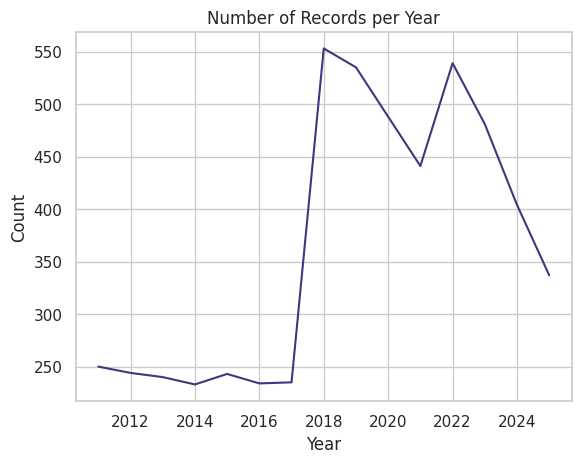

In [ ]:
counts = final['Year'].value_counts().sort_index()

plt.plot(counts.index, counts.values)
plt.title("Number of Records per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

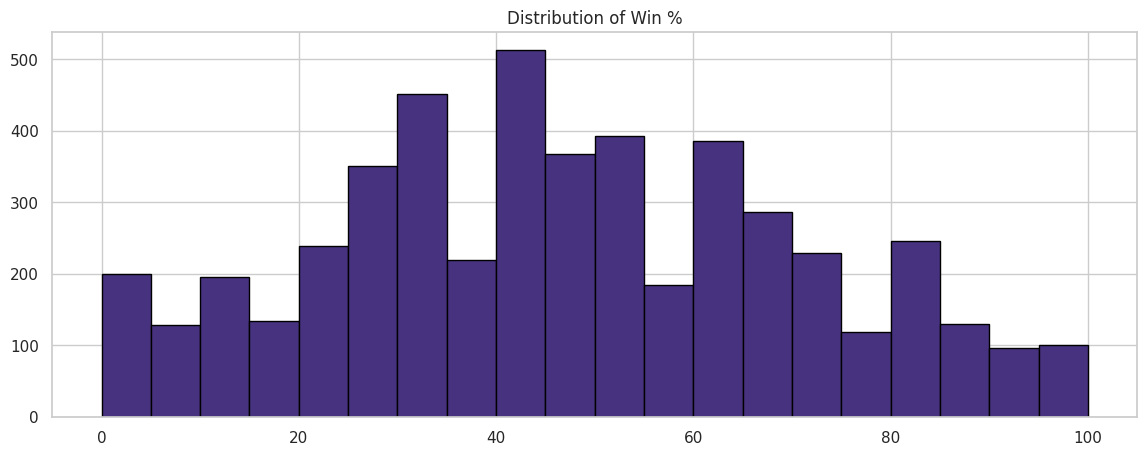

In [ ]:
combined[['Win Percentage']].hist(
    bins=20,
    figsize=(14,5),
    edgecolor='black'
)
plt.title('Distribution of Win %')
plt.show()

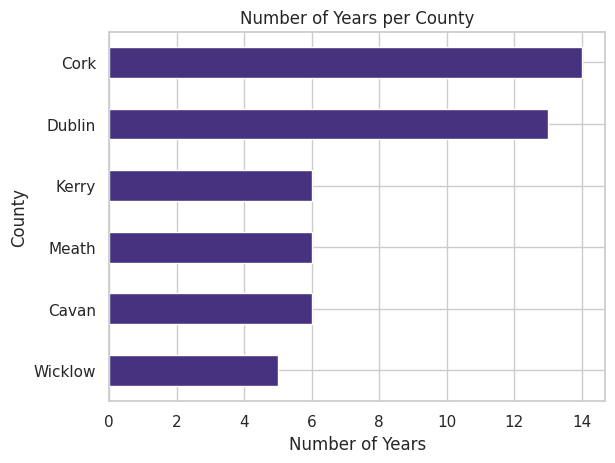

In [ ]:
counts = final.groupby('County')['Year'].nunique()

counts.sort_values().plot(kind='barh')
plt.title("Number of Years per County")
plt.xlabel("Number of Years")
plt.ylabel("County")
plt.show()

In [ ]:
county_years = final.groupby('County')['Year'].unique()

# Print nicely
for county, years in county_years.items():
    print(f"{county}: {years}")


Cavan: [2024 2023 2022 2021 2019 2018]
Cork: [2025 2024 2023 2022 2021 2019 2018 2017 2016 2015 2014 2013 2012 2011]
Dublin: [2025 2023 2022 2021 2019 2018 2017 2016 2015 2014 2013 2012 2011]
Kerry: [2024 2023 2022 2021 2019 2018]
Meath: [2024 2023 2022 2021 2019 2018]
Wicklow: [2025 2024 2022 2019 2018]


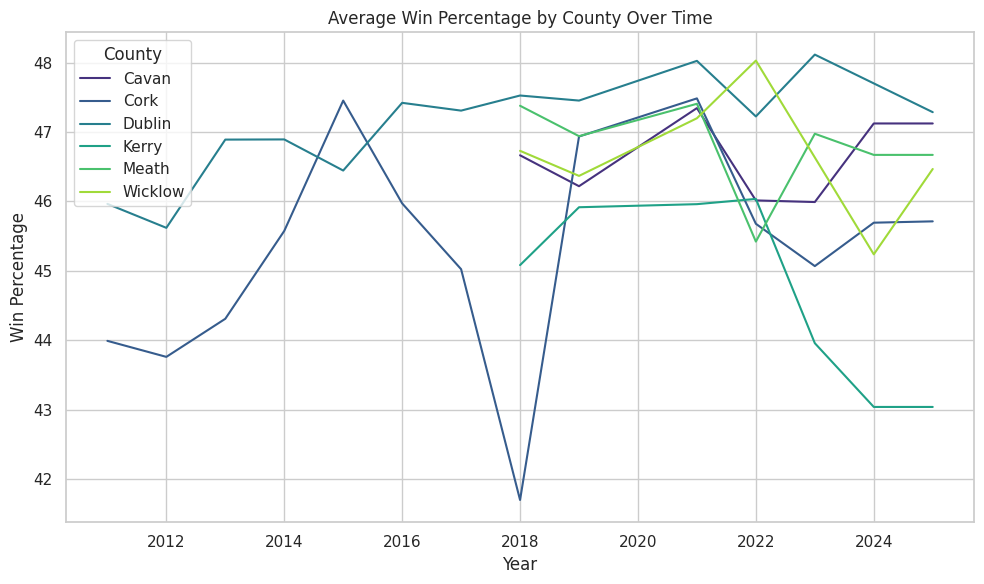

In [ ]:
grouped = final.groupby(['Year', 'County'])['Win Percentage'].mean().reset_index()

# Pivot so each county becomes a column
pivot = grouped.pivot(index='Year', columns='County', values='Win Percentage')

# Fill the gaps so lines connect
pivot = pivot.interpolate(method='linear')
# Plot
pivot.plot(figsize=(10, 6))

plt.title("Average Win Percentage by County Over Time")
plt.xlabel("Year")
plt.ylabel("Win Percentage")
plt.legend(title="County")
plt.tight_layout()

plt.show()

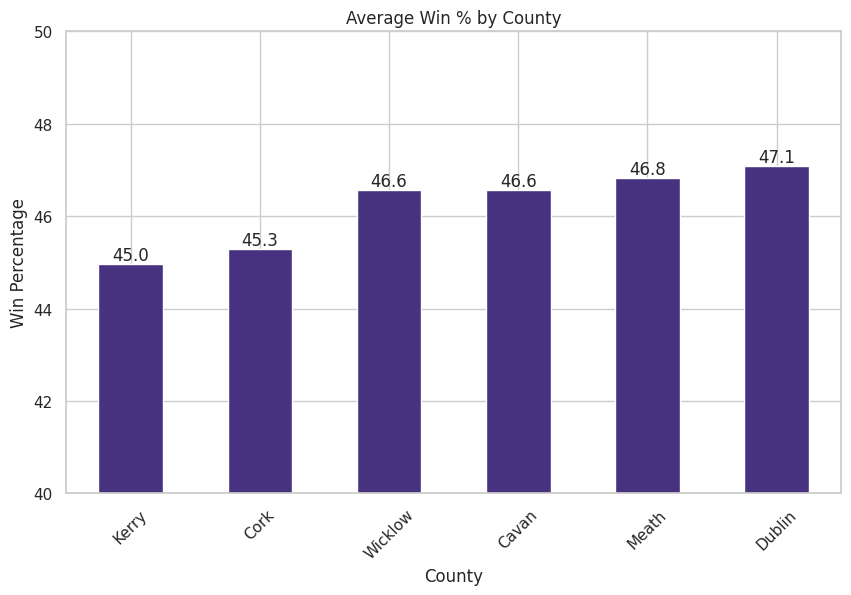

In [ ]:
avg = final.groupby('County')['Win Percentage'].mean()

ax = avg.sort_values().plot(kind='bar', figsize=(10,6))

plt.ylim(40, 50)
plt.title("Average Win % by County")
plt.ylabel("Win Percentage")
plt.xticks(rotation=45)

#  label bars
ax.bar_label(ax.containers[0], fmt='%.1f')

plt.show()

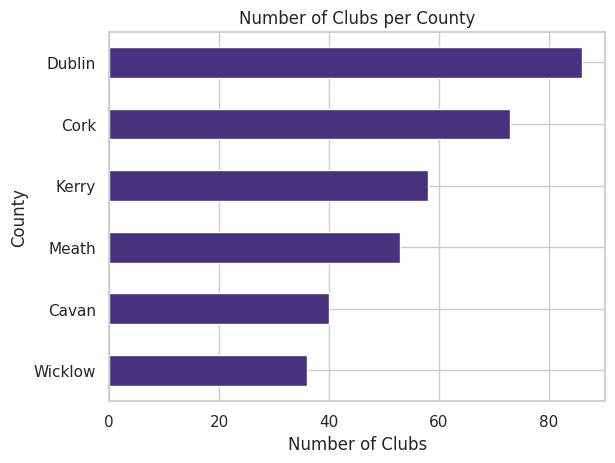

In [ ]:
counts = final.groupby('County')['team'].nunique()

counts.sort_values().plot(kind='barh')
plt.title("Number of Clubs per County")
plt.xlabel("Number of Clubs")
plt.ylabel("County")
plt.show()

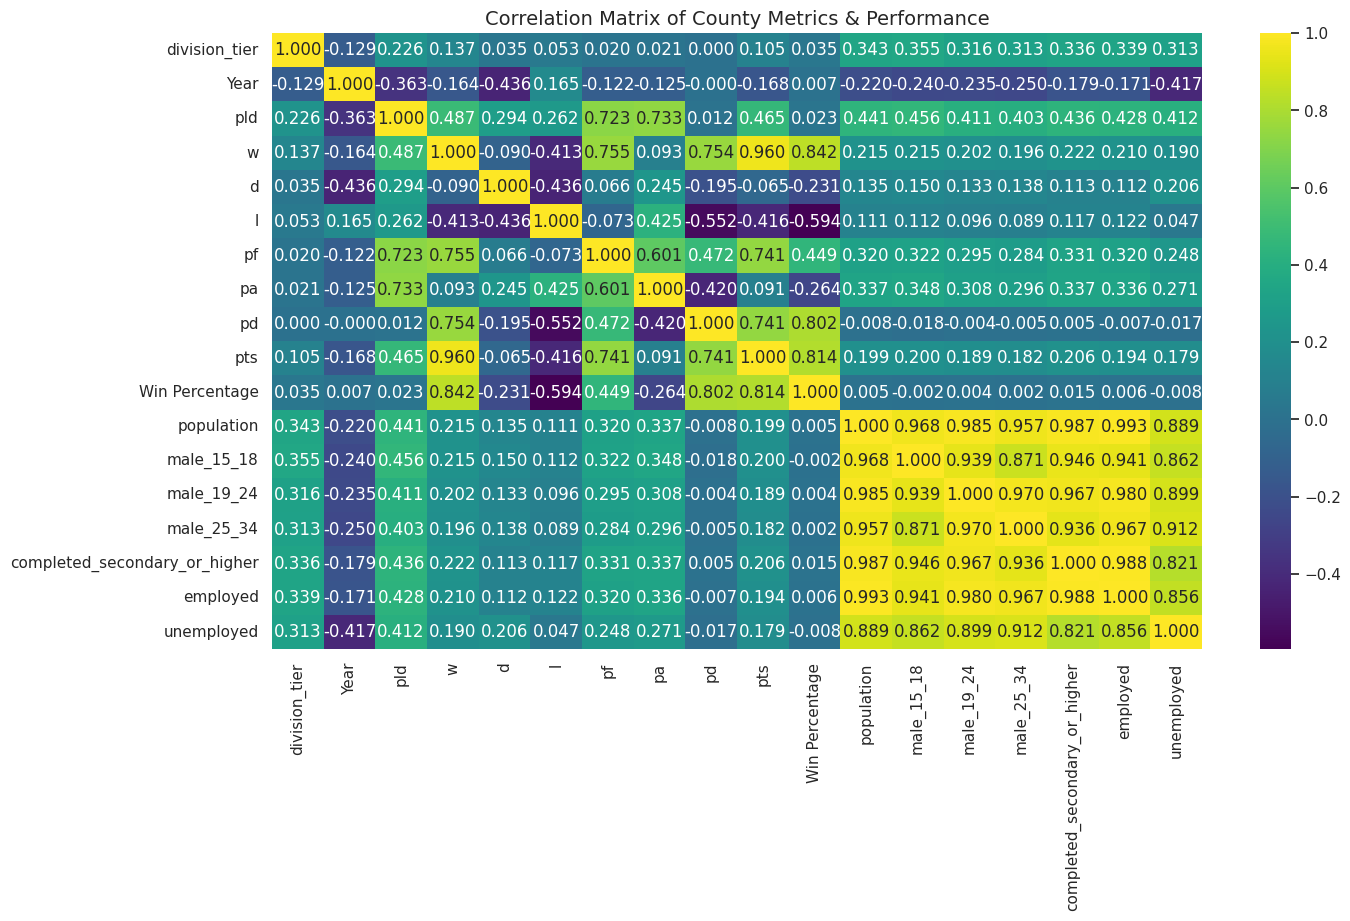

In [ ]:


plt.figure(figsize=(15, 8))
plt.title("Correlation Matrix of County Metrics & Performance", fontsize=14)
sns.heatmap(final.select_dtypes(include="number").corr(), annot=True, fmt=".3f",  cmap='viridis')
plt.show()



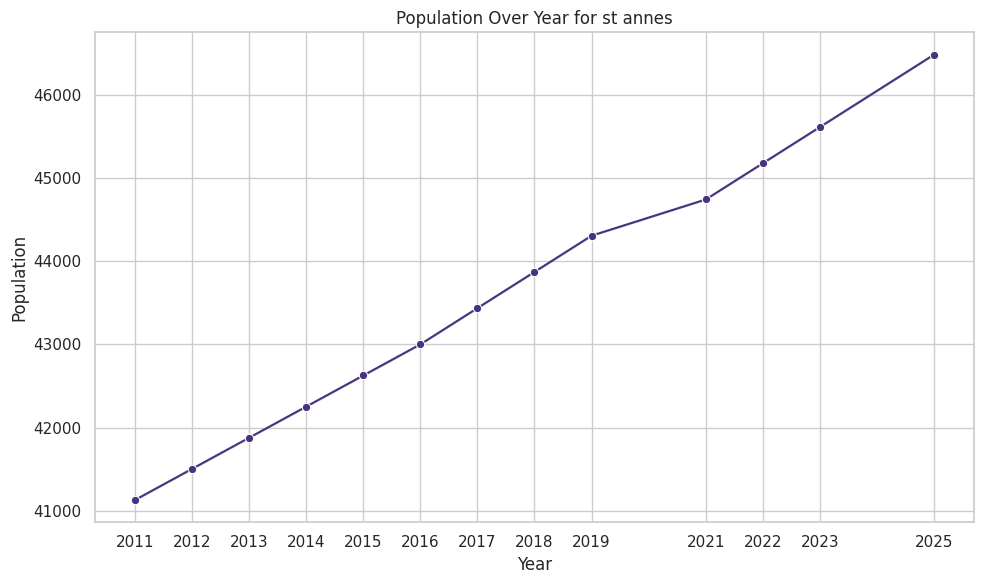

In [ ]:
# Choose a specific team for analysis (e.g., 'Skryne')
selected_team = "st annes"

# Filter the DataFrame for the selected team
team_ex = final[final['team'] == selected_team]

# Sort by year to ensure correct line plot progression
team_ex = team_ex.sort_values(by='Year')

plt.figure(figsize=(10, 6))
sns.lineplot(x='Year', y='population', data=team_ex, marker='o')
plt.title(f'Population Over Year for {selected_team}')
plt.xlabel('Year')
plt.ylabel('Population')
plt.xticks(team_ex['Year'].unique()) # Ensure all years are shown as x-ticks
plt.tight_layout()
plt.show()

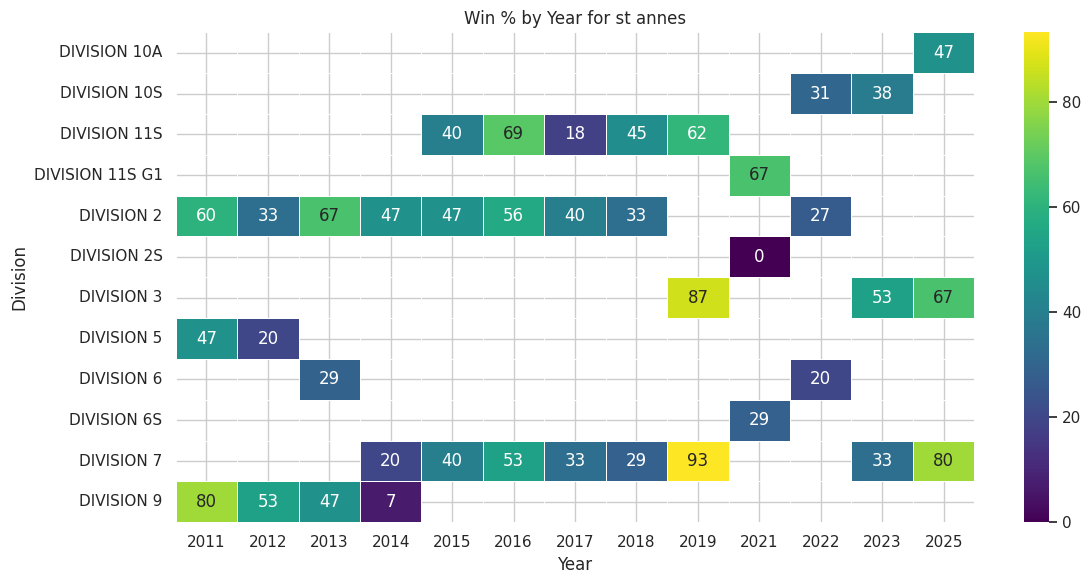

In [ ]:
selected_team = "st annes"

team_ex = final[final['team'] == selected_team].copy()



pivot_df = team_ex.pivot_table(
    index='Division',
    columns='Year',
    values='Win Percentage',
)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_df, annot=True, cmap='viridis', fmt='.0f', linewidths=0.5)

plt.title(f'Win % by Year for {selected_team}')
plt.xlabel('Year')
plt.ylabel('Division')
plt.tight_layout()
plt.show()

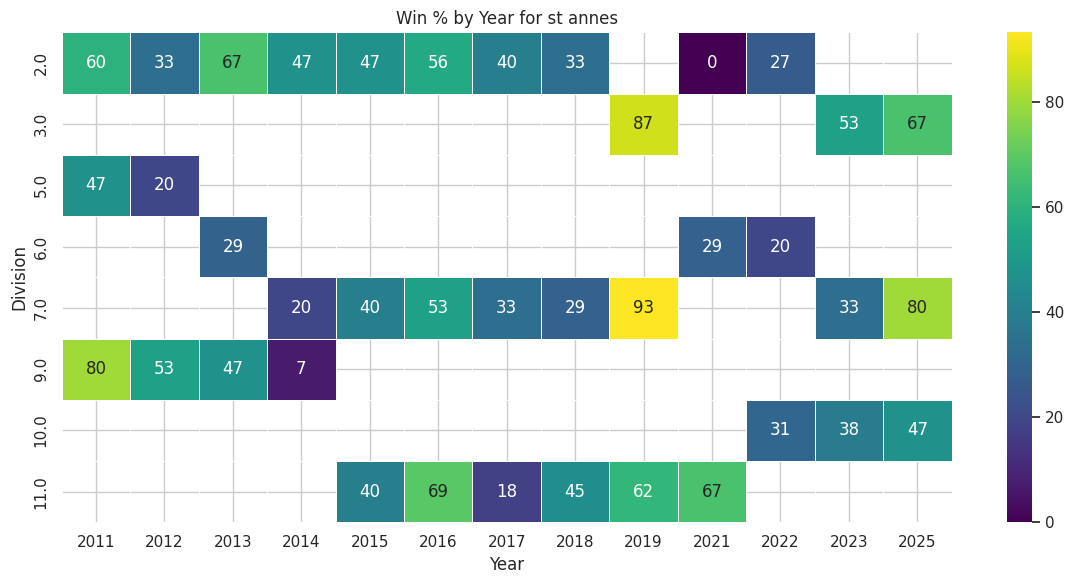

In [ ]:
selected_team = "st annes"

team_ex = final[final['team'] == selected_team].copy()


pivot_df = team_ex.pivot_table(
    index='division_tier',
    columns='Year',
    values='Win Percentage',
  #  aggfunc='mean'
)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_df, annot=True, cmap='viridis', fmt='.0f', linewidths=0.5)

plt.title(f'Win % by Year for {selected_team}')
plt.xlabel('Year')
plt.ylabel('Division')
plt.tight_layout()
plt.show()

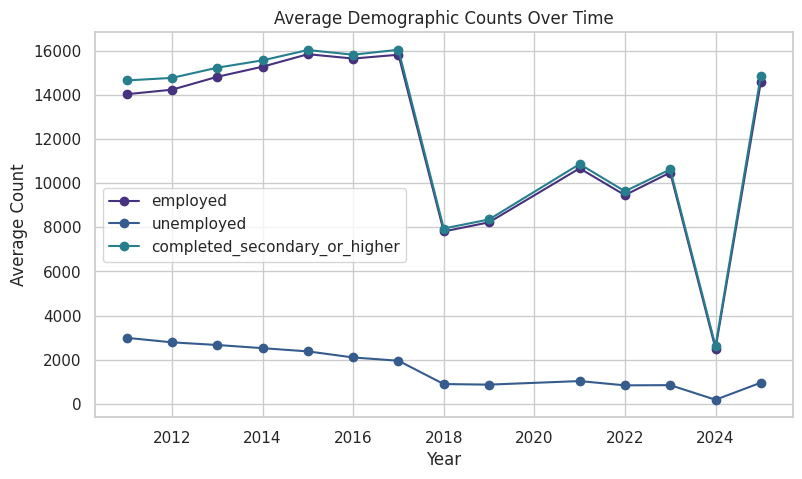

In [ ]:

# Average original socio-economic count columns by year
yearly_demo = final.groupby('Year')[
    ['employed', 'unemployed', 'completed_secondary_or_higher']
].mean()

plt.figure(figsize=(9,5))

for col in yearly_demo.columns:
    plt.plot(yearly_demo.index, yearly_demo[col], marker='o', label=col)

plt.title('Average Demographic Counts Over Time')
plt.xlabel('Year')
plt.ylabel('Average Count')
plt.legend()
plt.grid(True)
plt.show()

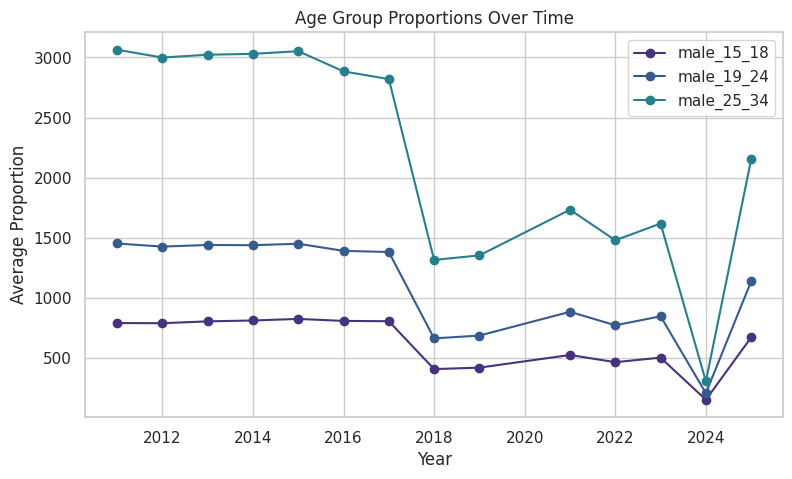

In [ ]:
# Group by year
yearly_age = final.groupby('Year')[
    ['male_15_18', 'male_19_24', 'male_25_34']
].mean()

plt.figure(figsize=(9, 5))

for col in yearly_age.columns:
    plt.plot(yearly_age.index, yearly_age[col], marker='o', label=col)

plt.title('Age Group Proportions Over Time')
plt.xlabel('Year')
plt.ylabel('Average Proportion')
plt.legend()
plt.grid(True)
plt.show()

# Demographic Ratios


Ratios

In [ ]:
# create ratios with correct column names
final['employment_rate'] = final['employed'] / final['population']
final['unemployment_rate'] = final['unemployed'] / final['population']
final['education_rate'] = final['completed_secondary_or_higher'] / final['population']
final['youth_proportion'] = final['male_15_18'] / final['population']
final['young_adult_proportion'] = final["male_19_24"] / final['population']
final['middle_adult_proportion'] = final["male_25_34"] / final['population']

corr2 = final[["division_tier", 'Win Percentage','employment_rate','unemployment_rate','education_rate','youth_proportion',"young_adult_proportion", "middle_adult_proportion"]].corr()
corr2

,division_tier,Win Percentage,employment_rate,unemployment_rate,education_rate,youth_proportion,young_adult_proportion,middle_adult_proportion
division_tier,1.000000,0.035216,0.105950,0.180599,0.007644,-0.158759,0.178325,0.284995
Win Percentage,0.035216,1.000000,0.020194,-0.020620,0.043329,0.013271,0.006943,-0.005307
employment_rate,0.105950,0.020194,1.000000,-0.376588,0.382862,-0.254655,0.187372,0.324601
unemployment_rate,0.180599,-0.020620,-0.376588,1.000000,-0.618943,-0.240686,0.250023,0.639346
education_rate,0.007644,0.043329,0.382862,-0.618943,1.000000,-0.123765,-0.083124,-0.184862
youth_proportion,-0.158759,0.013271,-0.254655,-0.240686,-0.123765,1.000000,-0.174999,-0.585579
young_adult_proportion,0.178325,0.006943,0.187372,0.250023,-0.083124,-0.174999,1.000000,0.493422
middle_adult_proportion,0.284995,-0.005307,0.324601,0.639346,-0.184862,-0.585579,0.493422,1.000000


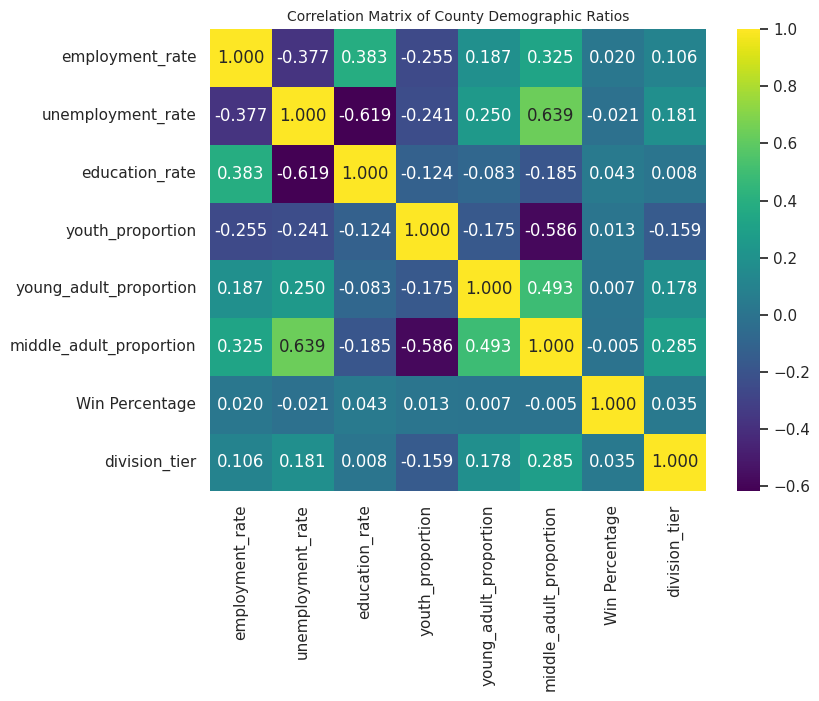

In [ ]:
# List of features to plot
features2 = [
 'employment_rate','unemployment_rate','education_rate','youth_proportion',"young_adult_proportion", "middle_adult_proportion", 'Win Percentage',"division_tier"
]
plt.figure(figsize=(8, 6))
plt.title("Correlation Matrix of County Demographic Ratios", fontsize=10,)
sns.heatmap(final[features2].corr(), annot=True, fmt=".3f", cmap='viridis')
plt.show()


# Final Dataset

In [ ]:
final.info()
final.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4969 entries, 0 to 4968
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   County                         4969 non-null   object 
 1   Division                       4969 non-null   object 
 2   division_tier                  4969 non-null   float64
 3   Year                           4969 non-null   int64  
 4   team                           4969 non-null   object 
 5   pld                            4969 non-null   int64  
 6   w                              4969 non-null   int64  
 7   d                              4969 non-null   int64  
 8   l                              4969 non-null   int64  
 9   pf                             4969 non-null   int64  
 10  pa                             4969 non-null   int64  
 11  pd                             4969 non-null   int64  
 12  pts                            4969 non-null   i

,County,Division,division_tier,Year,team,pld,w,d,l,pf,...,male_25_34,completed_secondary_or_higher,employed,unemployed,employment_rate,unemployment_rate,education_rate,youth_proportion,young_adult_proportion,middle_adult_proportion
0,Meath,DIVISION 1,1.0,2024,skryne,11,7,1,3,151,...,125.6,1459.6,1330.2,55.2,0.468942,0.019460,0.514560,0.040541,0.029190,0.044278
1,Meath,DIVISION 1,1.0,2024,summerhill,11,7,1,3,168,...,118.4,1531.8,1486.6,80.4,0.472807,0.025571,0.487183,0.027861,0.027352,0.037657
2,Meath,DIVISION 1,1.0,2024,ballinabrackey,11,5,4,2,147,...,87.0,657.4,705.4,40.2,0.450505,0.025674,0.419849,0.033976,0.045855,0.055563
3,Meath,DIVISION 1,1.0,2024,donaghmoreashbourne,11,6,2,3,153,...,896.2,8913.8,9133.0,576.8,0.477098,0.030131,0.465648,0.027258,0.029212,0.046817
4,Meath,DIVISION 1,1.0,2024,ratoath,11,5,3,3,136,...,523.0,5870.4,5945.8,364.4,0.505466,0.030978,0.499056,0.041758,0.051500,0.044461


In [ ]:
final.to_csv("/content/drive/MyDrive/Dissertation/Finaldataset.csv")

# Machine learning

Linear regression

In [ ]:

# Features
features = [
    'male_15_18',
    'male_19_24',
    "male_25_34",
    'population',
    'unemployed',
    'completed_secondary_or_higher',
]

X = final[features]
y = final['Win Percentage']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# Train
lr_model.fit(X_train, y_train)

# Predict + R²
y_pred_lr = lr_model.predict(X_test)
print("Linear Regression R²:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print("RMSE:", rmse)


Linear Regression R²: 0.005353483238002887
MAE: 19.57397691731472
RMSE: 23.884575308770735


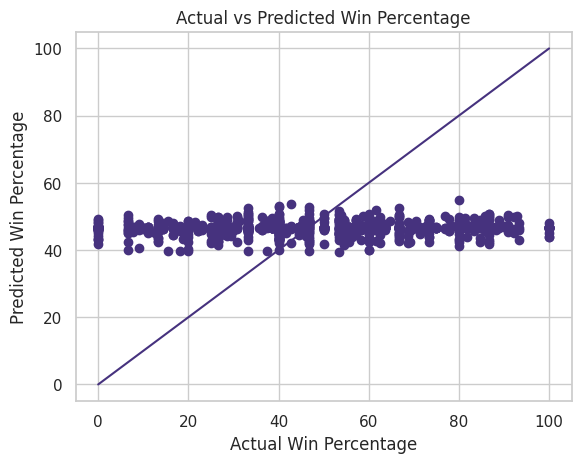

In [ ]:
plt.figure()
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Win Percentage")
plt.ylabel("Predicted Win Percentage")
plt.title("Actual vs Predicted Win Percentage")

# 45-degree reference line
min_val = min(y_test.min(), y_pred_lr.min())
max_val = max(y_test.max(), y_pred_lr.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

Random Forest regression

In [ ]:


# Model
rf_model = RandomForestRegressor(n_estimators=200,
    max_depth=5,
    min_samples_leaf=20,
    random_state=42,)

# Train
rf_model.fit(X_train, y_train)

# Predict + R²
y_pred_rf = rf_model.predict(X_test)
print("Random Forest R²:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("RMSE:", rmse)


Random Forest R²: 0.011720291135070005
MAE: 19.433595535183166
RMSE: 23.808009095237324


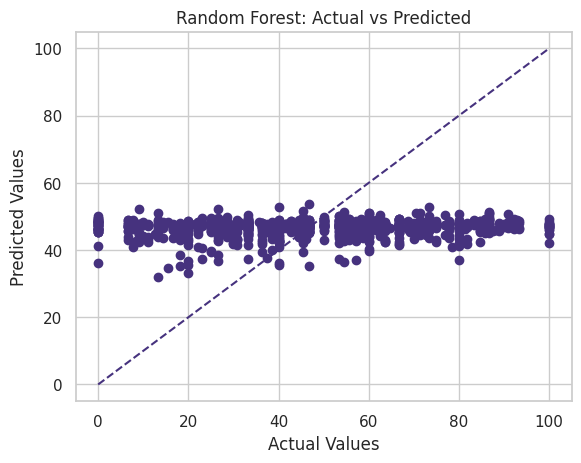

In [ ]:
plt.scatter(y_test, y_pred_rf)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

In [ ]:
gbr = GradientBoostingRegressor()

gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)
print("Gradient Boosting R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Gradient Boosting R²: -0.0011197156995832458
MAE: 19.503295561824515
RMSE: 23.962170147131943


# Machine learning ratios

In [ ]:
# Features
featuresR = [
    'employment_rate',
    'unemployment_rate',
    'education_rate',
    'youth_proportion',
    'young_adult_proportion',
    'middle_adult_proportion'
]

X2 = final[featuresR]
y2 = final['Win Percentage']

# Split
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Model
lr2_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# Train
lr2_model.fit(X2_train, y2_train)

# Predict + R²
y2_pred_lr = lr2_model.predict(X2_test)
print("Linear Regression R²:", r2_score(y2_test, y2_pred_lr))
print("MAE:", mean_absolute_error(y2_test, y2_pred_lr))
rmse = np.sqrt(mean_squared_error(y2_test, y2_pred_lr))
print("RMSE:", rmse)

Linear Regression R²: 0.001975946419115693
MAE: 19.561548372602275
RMSE: 23.92509355480435


In [ ]:


# Model
rf2_model = RandomForestRegressor(n_estimators=200,
    max_depth=5,
    min_samples_leaf=20,
    random_state=42,)

# Train
rf2_model.fit(X2_train, y2_train)

# Predict + R²
y2_pred_rf = rf2_model.predict(X2_test)
print("Random Forest R²:", r2_score(y2_test, y2_pred_rf))
print("MAE:", mean_absolute_error(y2_test, y2_pred_rf))
rmse = np.sqrt(mean_squared_error(y2_test, y2_pred_rf))
print("RMSE:", rmse)


Random Forest R²: 0.005980218517260161
MAE: 19.49625247394217
RMSE: 23.8770491853998


In [ ]:
gbr = GradientBoostingRegressor()

gbr.fit(X2_train, y2_train)
y2_pred = gbr.predict(X2_test)
print("Gradient Boosting R²:", r2_score(y2_test, y2_pred))
print("MAE:", mean_absolute_error(y2_test, y2_pred))
print("RMSE:", np.sqrt(mean_squared_error(y2_test, y2_pred)))

Gradient Boosting R²: -0.0012957786319509612
MAE: 19.588964939119467
RMSE: 23.964277120156286


# Clustering

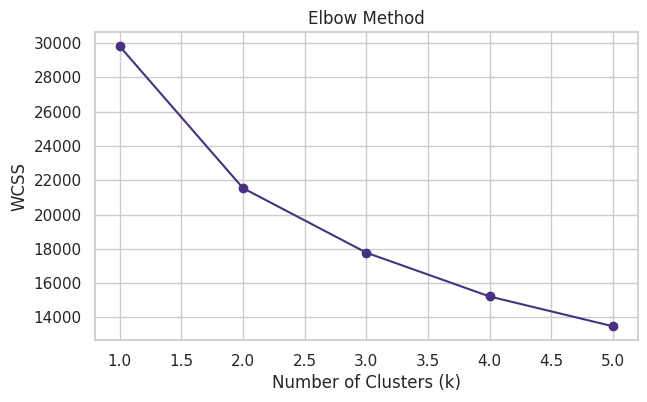

In [ ]:

features = [
    'employment_rate',
    'unemployment_rate',
    'education_rate',
    'youth_proportion',
    'young_adult_proportion',
    'middle_adult_proportion'
]

# Select features
X = final[features]

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method
inertia = []

for k in range(1, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Plot
plt.figure(figsize=(7,4))
plt.plot(range(1, 6), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.show()

In [ ]:
clustered_data = []

# Use all teams together, not split by division tier
sub = final.copy()
X = sub[features]

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Test silhouette scores
silhouette_scores = {}

for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores[k] = score
    print(f"k={k}: {score:.3f}")

# Choose best k
best_k = max(silhouette_scores, key=silhouette_scores.get)
print("Best k:", best_k)

# Final clustering
km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
sub['cluster'] = km.fit_predict(X_scaled)

clustered_final = sub

k=2: 0.329
k=3: 0.277
k=4: 0.214
k=5: 0.215
Best k: 2


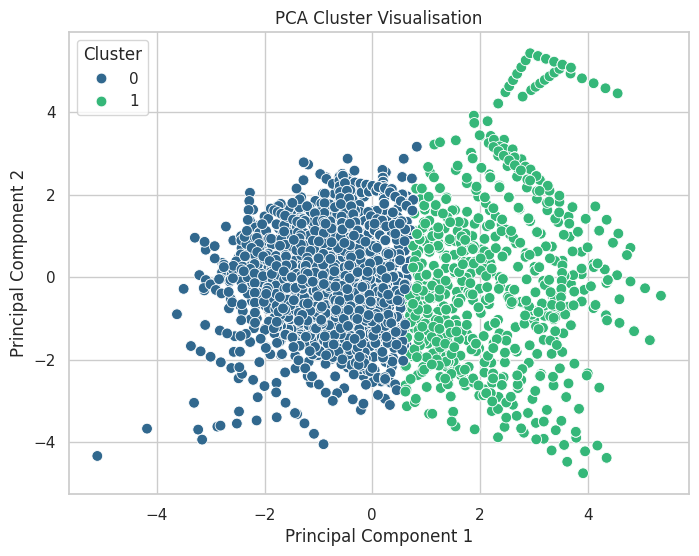

In [ ]:
# Use all clustered data
sub = clustered_final.copy()

X = sub[features]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA to 2 components
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

sub['PC1'] = pcs[:, 0]
sub['PC2'] = pcs[:, 1]

# Plot clusters
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=sub,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='viridis',
    s=60
)

plt.title('PCA Cluster Visualisation')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

In [ ]:
print("\nCluster Counts:")
print(sub['cluster'].value_counts())

print("\nAverage Win % by Cluster:")
print(sub.groupby('cluster')['Win Percentage'].mean())

print("\nFeature Means by Cluster:")
print(sub.groupby('cluster')[features].mean())


Cluster Counts:
cluster
0    3655
1    1314
Name: count, dtype: int64

Average Win % by Cluster:
cluster
0    47.056063
1    45.026880
Name: Win Percentage, dtype: float64

Feature Means by Cluster:
         employment_rate  unemployment_rate  education_rate  youth_proportion  \
cluster                                                                         
0               0.444082           0.038137        0.475009          0.027453   
1               0.446353           0.073804        0.421486          0.022129   

         young_adult_proportion  middle_adult_proportion  
cluster                                                   
0                      0.033773                 0.053746  
1                      0.041088                 0.091561  


# Clusters By Tier

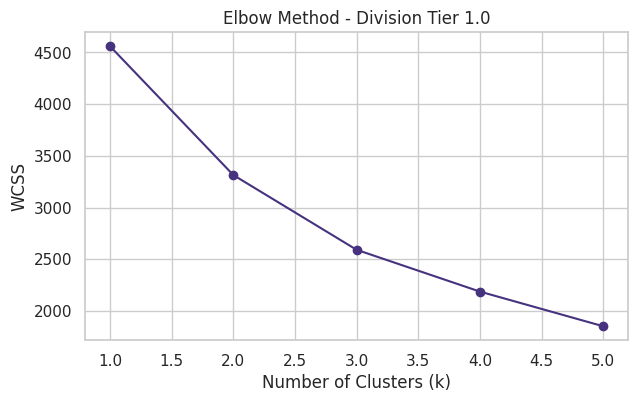

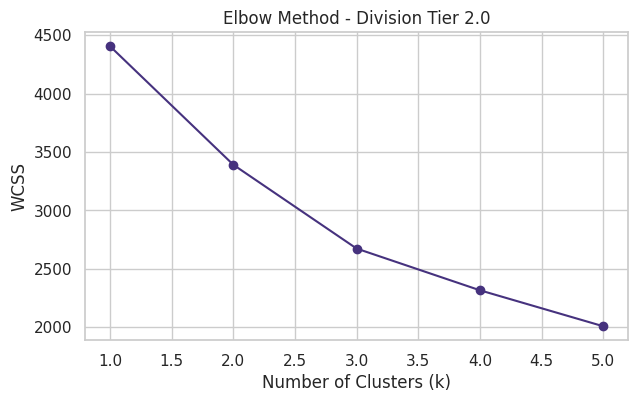

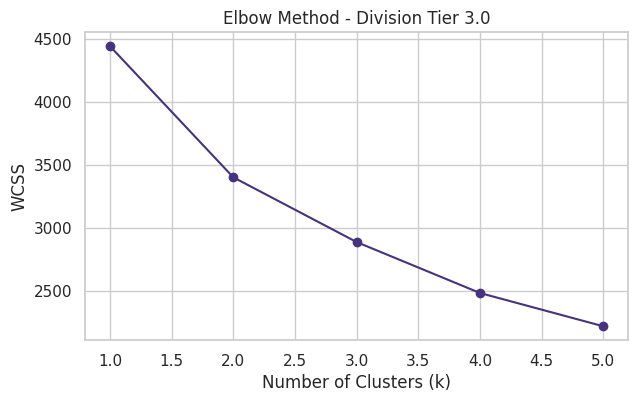

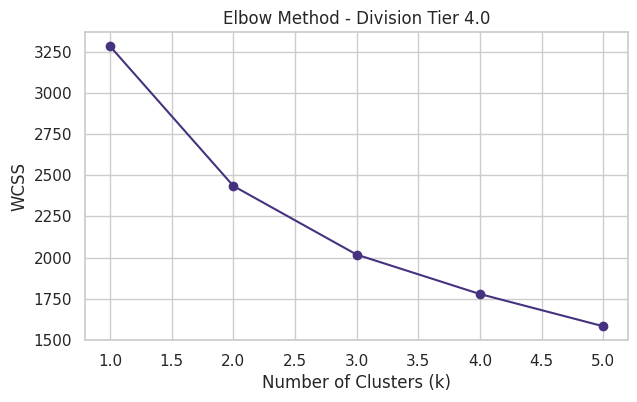

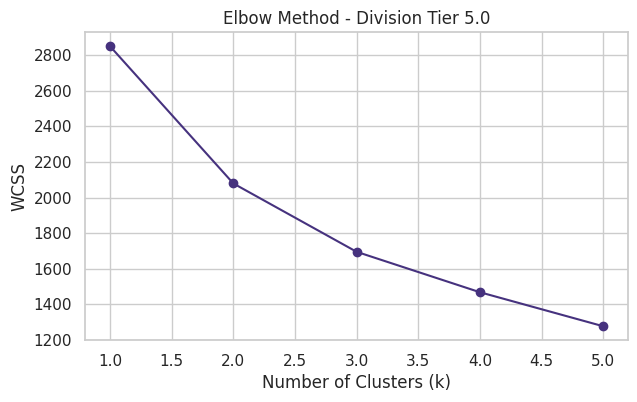

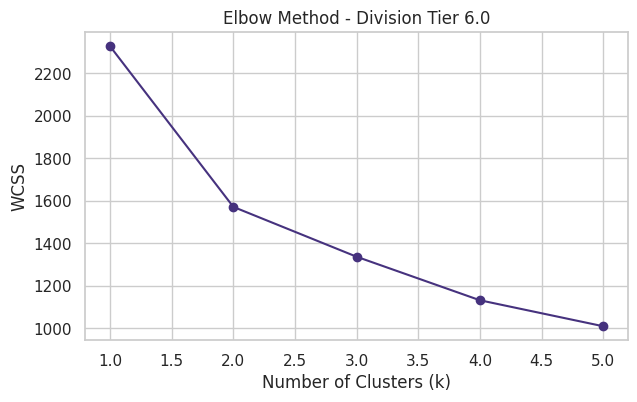

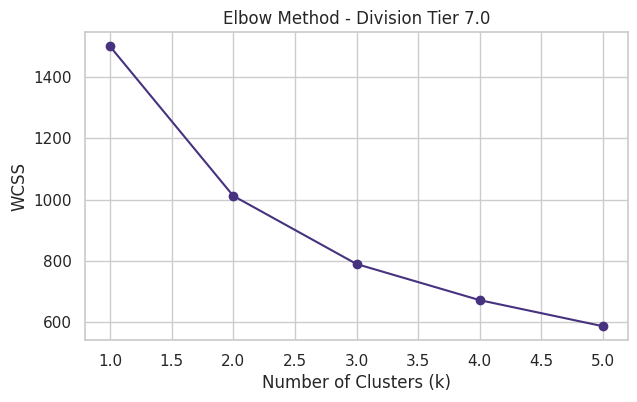

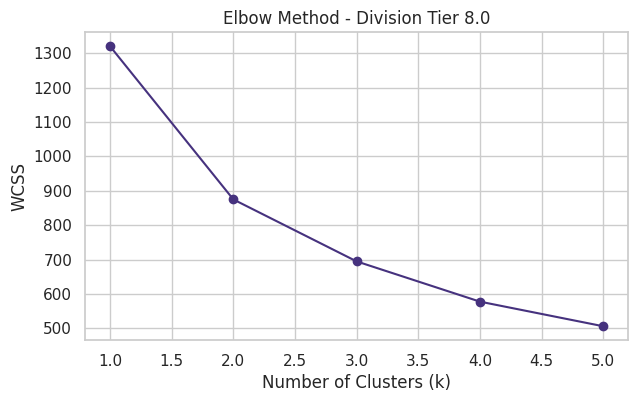

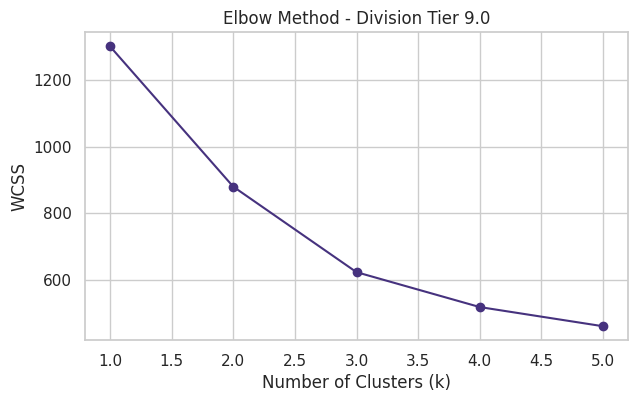

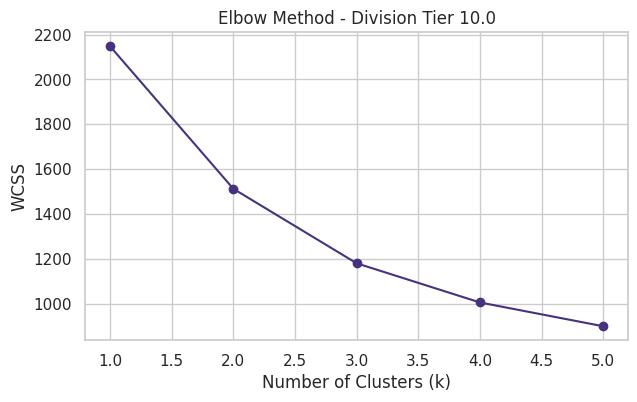

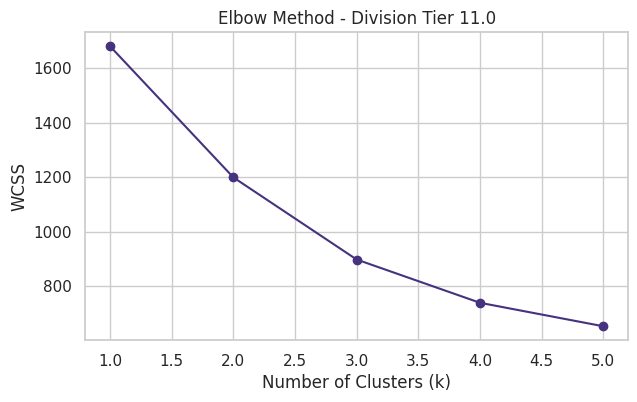

In [ ]:

features = [
    'employment_rate',
    'unemployment_rate',
    'education_rate',
    'youth_proportion',
    'young_adult_proportion',
    'middle_adult_proportion'
]


for div in sorted(final['division_tier'].dropna().unique()):

    sub = final[final['division_tier'] == div].copy()
    X = sub[features]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    inertia = []

    for k in range(1, 6):
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X_scaled)
        inertia.append(km.inertia_)

    plt.figure(figsize=(7,4))
    plt.plot(range(1, 6), inertia, marker='o')
    plt.title(f'Elbow Method - Division Tier {div}')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('WCSS')
    plt.grid(True)
    plt.show()

In [ ]:
clustered_data = []

for div in sorted(final['division_tier'].dropna().unique()):

    print(f"\nDivision Tier {div}")

    sub = final[final['division_tier'] == div].copy()
    X = sub[features]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    silhouette_scores = {}

    for k in range(2, 6):
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        silhouette_scores[k] = score
        print(f"k={k}: {score:.3f}")

    best_k = max(silhouette_scores, key=silhouette_scores.get)
    print("Best k:", best_k)

    km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    sub['cluster'] = km.fit_predict(X_scaled)

    clustered_data.append(sub)

clustered_final = pd.concat(clustered_data, ignore_index=True)


Division Tier 1.0
k=2: 0.406
k=3: 0.248
k=4: 0.240
k=5: 0.259
Best k: 2

Division Tier 2.0
k=2: 0.312
k=3: 0.252
k=4: 0.211
k=5: 0.216
Best k: 2

Division Tier 3.0
k=2: 0.328
k=3: 0.192
k=4: 0.196
k=5: 0.193
Best k: 2

Division Tier 4.0
k=2: 0.304
k=3: 0.263
k=4: 0.203
k=5: 0.197
Best k: 2

Division Tier 5.0
k=2: 0.303
k=3: 0.274
k=4: 0.214
k=5: 0.226
Best k: 2

Division Tier 6.0
k=2: 0.343
k=3: 0.235
k=4: 0.222
k=5: 0.214
Best k: 2

Division Tier 7.0
k=2: 0.295
k=3: 0.295
k=4: 0.264
k=5: 0.269
Best k: 3

Division Tier 8.0
k=2: 0.347
k=3: 0.337
k=4: 0.266
k=5: 0.268
Best k: 2

Division Tier 9.0
k=2: 0.347
k=3: 0.357
k=4: 0.293
k=5: 0.282
Best k: 3

Division Tier 10.0
k=2: 0.285
k=3: 0.276
k=4: 0.252
k=5: 0.238
Best k: 2

Division Tier 11.0
k=2: 0.289
k=3: 0.301
k=4: 0.267
k=5: 0.279
Best k: 3


In [ ]:
for div in sorted(clustered_final['division_tier'].dropna().unique()):

    print(f"\nDivision Tier {div}")

    sub = clustered_final[clustered_final['division_tier'] == div]

    print("\nCluster Counts:")
    print(sub['cluster'].value_counts())

    print("\nAverage Win % by Cluster:")
    print(sub.groupby('cluster')['Win Percentage'].mean())

    print("\nFeature Means by Cluster:")
    print(sub.groupby('cluster')[features].mean())


Division Tier 1.0

Cluster Counts:
cluster
0    632
1    128
Name: count, dtype: int64

Average Win % by Cluster:
cluster
0    45.018797
1    47.428359
Name: Win Percentage, dtype: float64

Feature Means by Cluster:
         employment_rate  unemployment_rate  education_rate  youth_proportion  \
cluster                                                                         
0               0.444668           0.038778        0.472446          0.028057   
1               0.430990           0.073909        0.423029          0.021746   

         young_adult_proportion  middle_adult_proportion  
cluster                                                   
0                      0.033995                 0.054136  
1                      0.045902                 0.091314  

Division Tier 2.0

Cluster Counts:
cluster
1    573
0    161
Name: count, dtype: int64

Average Win % by Cluster:
cluster
0    42.221925
1    46.821832
Name: Win Percentage, dtype: float64

Feature Means by Cluster:
     

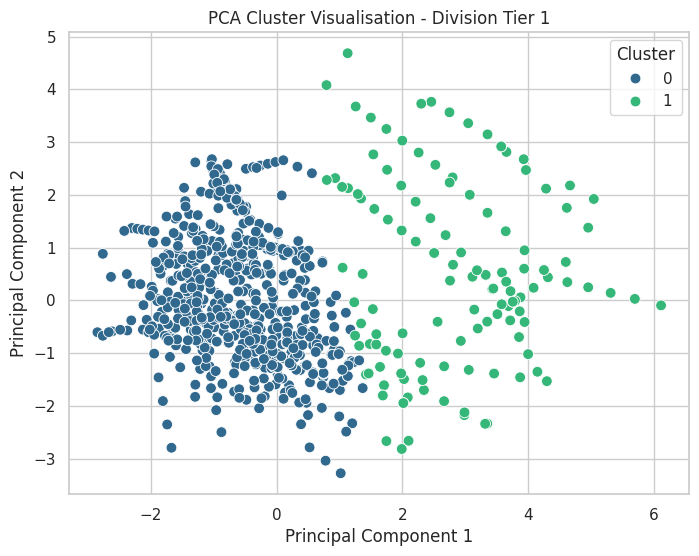

In [ ]:


selected_division = 1

sub = clustered_final[clustered_final['division_tier'] == selected_division].copy()

X = sub[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

sub['PC1'] = pcs[:, 0]
sub['PC2'] = pcs[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=sub,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='viridis',
    s=60
)

plt.title(f'PCA Cluster Visualisation - Division Tier {selected_division}')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

/tmp/ipykernel_4099/2741769591.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x='Tier', y='Gap', palette= "viridis")


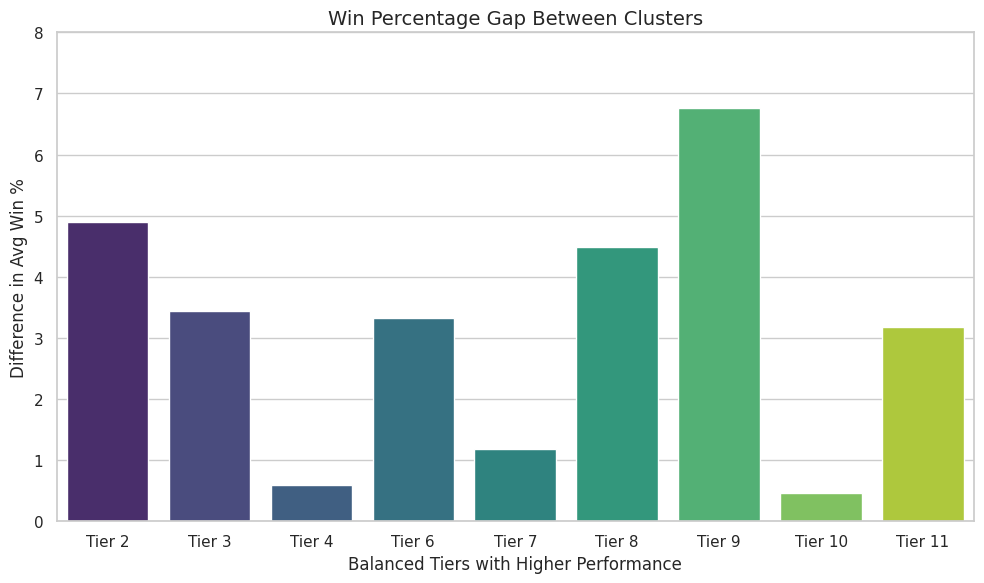

In [ ]:

# Data
df = pd.DataFrame({
    'Tier': ['Tier 2', 'Tier 3', 'Tier 4', 'Tier 6', 'Tier 7', 'Tier 8', 'Tier 9', 'Tier 10', 'Tier 11'],
    'Gap': [4.90, 3.44, 0.60, 3.33, 1.19, 4.48, 6.77, 0.46, 3.18]
})

# Setup Style
#sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plot
ax = sns.barplot(data=df, x='Tier', y='Gap', palette= "viridis")

# Polish
plt.title('Win Percentage Gap Between Clusters', fontsize=14, )
plt.ylabel('Difference in Avg Win %')
plt.xlabel("Balanced Tiers with Higher Performance")
plt.ylim(0, 8)
plt.tight_layout()

plt.show()
